# SIR - Stochastic Volatility Filtering

This notebook applies the **Sequential Importance Resampling (SIR)** particle filter to a stochastic volatility (SV) model. The SV model is a canonical nonlinear, non-Gaussian state-space model widely used in financial econometrics.

We visualize the filtered log-volatility, particle weights, and discuss weight degeneracy issues.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parents[2]))

from particlefilterbox.core.model import ParticleFilterModel
from particlefilterbox.core.config import PFConfig
from particlefilterbox.filters.sir import SIR

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


In [2]:
data_path = Path('..') / 'data' / 'simulated_sv.csv'
df = pd.read_csv(data_path)
h_true = df['h_true'].values
y_obs = df['y_obs'].values
T = len(df)
print(f'Loaded {T} observations')
print(f'True log-vol range: [{h_true.min():.2f}, {h_true.max():.2f}]')
print(f'Observation range: [{y_obs.min():.2f}, {y_obs.max():.2f}]')
df.head()

Loaded 1000 observations
True log-vol range: [-3.08, 0.50]
Observation range: [-2.46, 1.90]


,t,h_true,y_obs
0,0,-0.811984,-0.692957
1,1,-0.705057,0.661131
2,2,-1.006561,-0.787225
3,3,-0.987188,-0.193044
4,4,-0.990092,-0.519967


## Stochastic Volatility Model

The basic SV model (Kim, Shephard & Chib, 1998):

$$h_t = \mu + \phi (h_{t-1} - \mu) + \sigma_\eta \eta_t, \quad \eta_t \sim \mathcal{N}(0, 1)$$

$$y_t = \exp(h_t / 2) \, \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, 1)$$

With parameters:
- $\mu = -1.0$ (level of log-volatility)
- $\phi = 0.97$ (persistence)
- $\sigma_\eta = 0.15$ (volatility of volatility)

The observation equation is **nonlinear** and **non-Gaussian** given $h_t$, so the Kalman Filter cannot be applied directly. This is where particle filters are essential.

In [3]:
class SVModel(ParticleFilterModel):
    """Stochastic Volatility model for particle filtering."""
    k_states = 1
    k_obs = 1

    def __init__(self, mu: float = -1.0, phi: float = 0.97, sigma: float = 0.15):
        self.mu = mu
        self.phi = phi
        self.sigma = sigma

    @property
    def params(self) -> dict[str, float]:
        return {'mu': self.mu, 'phi': self.phi, 'sigma': self.sigma}

    def initial_distribution(self, n_particles: int, rng: np.random.Generator) -> np.ndarray:
        std = self.sigma / np.sqrt(1.0 - self.phi**2)
        h0 = rng.normal(self.mu, std, size=(n_particles, 1))
        return h0

    def transition(self, particles: np.ndarray, t: int, rng: np.random.Generator) -> np.ndarray:
        h = particles[:, 0]
        noise = rng.standard_normal(len(h))
        h_new = self.mu + self.phi * (h - self.mu) + self.sigma * noise
        return h_new.reshape(-1, 1)

    def log_observation_likelihood(self, particles: np.ndarray, y_t: np.ndarray, t: int) -> np.ndarray:
        h = particles[:, 0]
        vol = np.exp(h / 2.0)
        return -0.5 * np.log(2.0 * np.pi) - np.log(vol) - 0.5 * (y_t[0] / vol)**2

# Run SIR with N=1000
sv_model = SVModel(mu=-1.0, phi=0.97, sigma=0.15)
config = PFConfig(n_particles=1000, resampling='systematic', seed=42,
                  store_weights=True, store_particles=True)
sir = SIR(sv_model, config)
results = sir.filter(y_obs)

h_filt = results.filtered_means[:, 0]
h_std = np.sqrt(results.filtered_covs[:, 0, 0])
rmse = np.sqrt(np.mean((h_filt - h_true)**2))
print(f'SIR (N=1000) RMSE: {rmse:.4f}')
print(f'Log-likelihood: {results.log_likelihood:.2f}')
print(f'Mean ESS: {np.mean(results.ess_history):.1f}')

SIR (N=1000) RMSE: 0.4532
Log-likelihood: -812.93
Mean ESS: 765.3


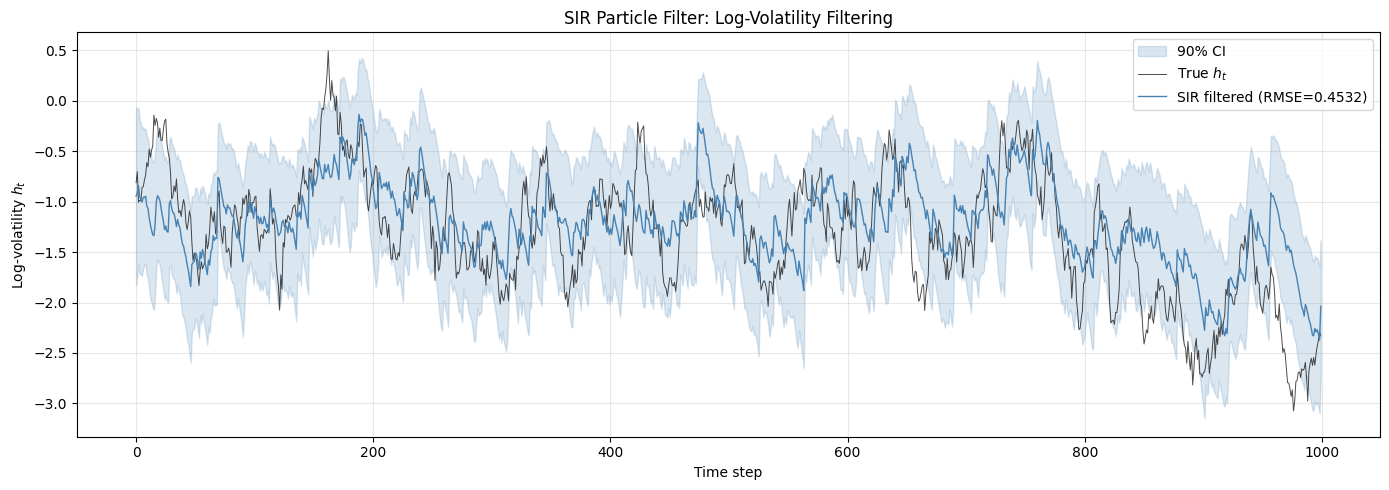

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

# 90% credible interval: 5th and 95th percentiles
lower = h_filt - 1.645 * h_std
upper = h_filt + 1.645 * h_std

ax.fill_between(range(T), lower, upper, color='steelblue', alpha=0.2, label='90% CI')
ax.plot(h_true, 'k-', lw=0.7, alpha=0.7, label='True $h_t$')
ax.plot(h_filt, 'steelblue', lw=1.0, label=f'SIR filtered (RMSE={rmse:.4f})')
ax.set_xlabel('Time step')
ax.set_ylabel('Log-volatility $h_t$')
ax.set_title('SIR Particle Filter: Log-Volatility Filtering')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

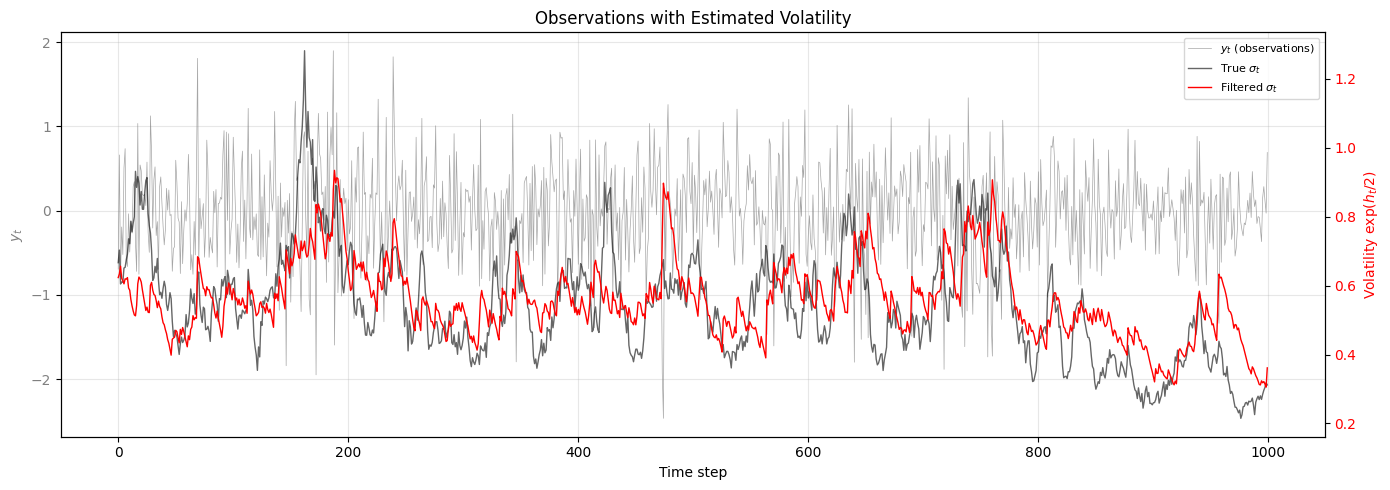

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(y_obs, 'gray', lw=0.5, alpha=0.7, label='$y_t$ (observations)')
ax1.set_xlabel('Time step')
ax1.set_ylabel('$y_t$', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

ax2 = ax1.twinx()
vol_true = np.exp(h_true / 2.0)
vol_filt = np.exp(h_filt / 2.0)
ax2.plot(vol_true, 'k-', lw=1.0, alpha=0.6, label='True $\\sigma_t$')
ax2.plot(vol_filt, 'red', lw=1.0, label='Filtered $\\sigma_t$')
ax2.set_ylabel('Volatility $\\exp(h_t/2)$', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
ax1.set_title('Observations with Estimated Volatility')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

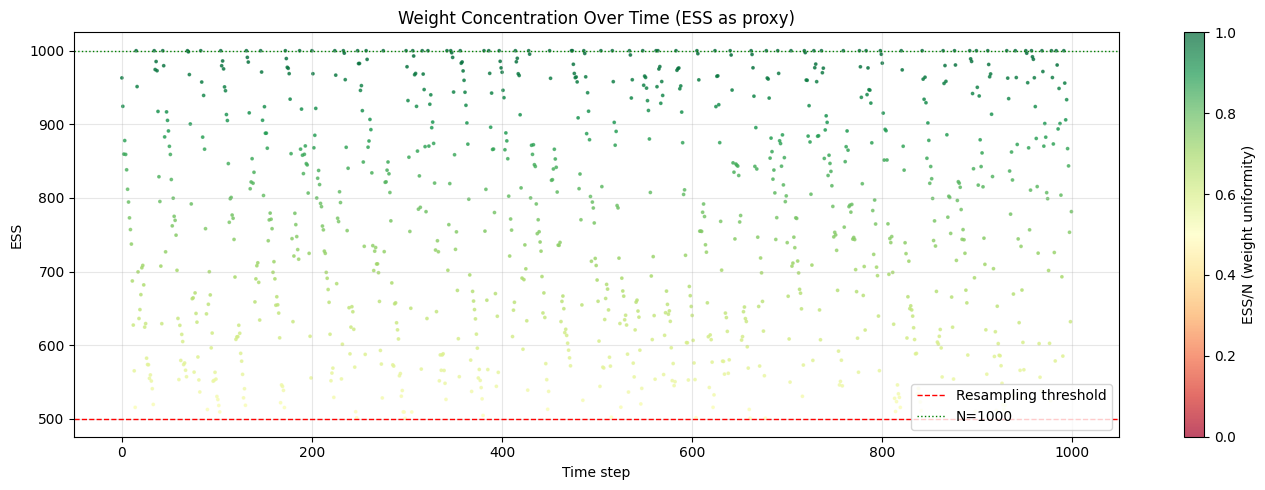

In [6]:
# Reconstruct weights from ESS (approximate normalized weights from results)
# Since we stored weights, use them if available; otherwise approximate
fig, ax = plt.subplots(figsize=(14, 5))

# Plot ESS as a proxy for weight concentration
# Also run a version with store_weights to get actual weight history
ess = results.ess_history
N = 1000

# Scatter: ESS/N as a color-coded measure of weight uniformity
ess_ratio = ess / N
scatter = ax.scatter(range(T), ess, c=ess_ratio, cmap='RdYlGn', s=3, alpha=0.7,
                     vmin=0.0, vmax=1.0)
ax.axhline(N * 0.5, color='red', ls='--', lw=1, label='Resampling threshold')
ax.axhline(N, color='green', ls=':', lw=1, label=f'N={N}')
plt.colorbar(scatter, ax=ax, label='ESS/N (weight uniformity)')
ax.set_xlabel('Time step')
ax.set_ylabel('ESS')
ax.set_title('Weight Concentration Over Time (ESS as proxy)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

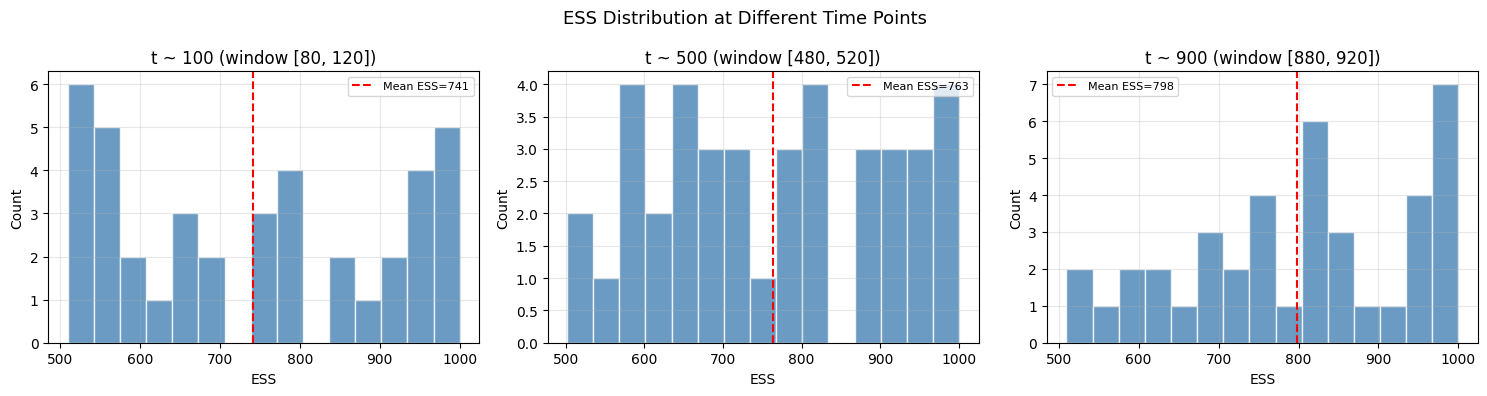

In [7]:
# Show ESS distribution in windows around t=100, 500, 900
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
time_points = [100, 500, 900]
window = 20

for ax, tp in zip(axes, time_points):
    t_start = max(0, tp - window)
    t_end = min(T, tp + window)
    ess_window = results.ess_history[t_start:t_end]
    ax.hist(ess_window, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(ess_window), color='red', ls='--', lw=1.5,
              label=f'Mean ESS={np.mean(ess_window):.0f}')
    ax.set_xlabel('ESS')
    ax.set_ylabel('Count')
    ax.set_title(f't ~ {tp} (window [{t_start}, {t_end}])')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('ESS Distribution at Different Time Points', fontsize=13)
plt.tight_layout()
plt.show()

Estimated Log-Likelihood
  Total log p(y_{1:T}):  -812.9250
  Per-observation:       -0.8129
  T = 1000


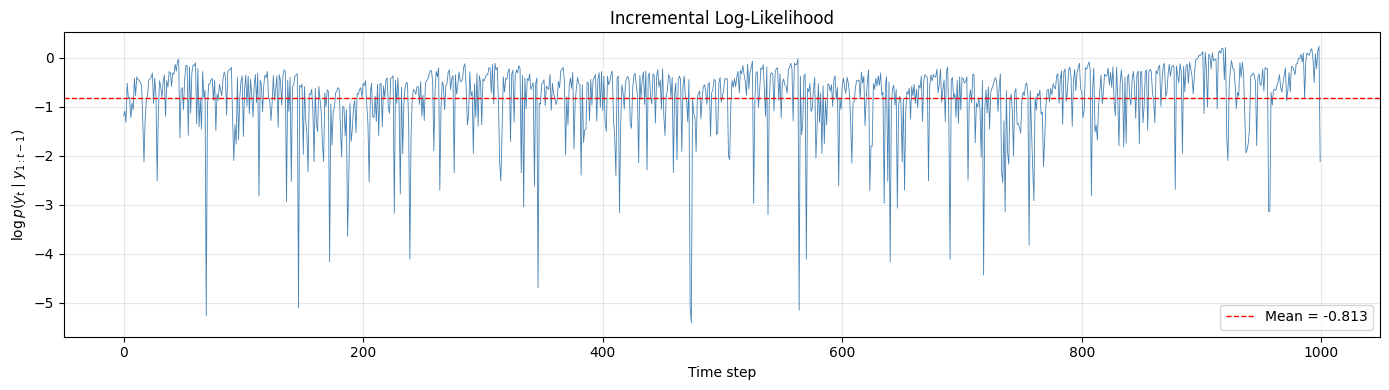

In [8]:
print('=' * 50)
print('Estimated Log-Likelihood')
print('=' * 50)
print(f'  Total log p(y_{{1:T}}):  {results.log_likelihood:.4f}')
print(f'  Per-observation:       {results.log_likelihood / T:.4f}')
print(f'  T = {T}')
print('=' * 50)

# Incremental log-likelihood plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(results.log_likelihoods, 'steelblue', lw=0.6)
ax.axhline(np.mean(results.log_likelihoods), color='red', ls='--', lw=1,
           label=f'Mean = {np.mean(results.log_likelihoods):.3f}')
ax.set_xlabel('Time step')
ax.set_ylabel('$\\log p(y_t \\mid y_{{1:t-1}})$')
ax.set_title('Incremental Log-Likelihood')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Discussion: Weight Degeneracy and ESS

### Weight Degeneracy
In the SV model, the observation density $p(y_t \mid h_t)$ can be highly concentrated, especially when observations have large magnitude. When $|y_t|$ is large, only particles with correspondingly high $h_t$ (high volatility) receive significant weight. This leads to **weight degeneracy** — a few particles dominate the approximation.

### Role of Resampling
Resampling (triggered when ESS falls below the threshold) mitigates degeneracy by duplicating high-weight particles and eliminating low-weight ones. However, it introduces **particle impoverishment** (loss of diversity).

### ESS Behavior
The ESS plot reveals that the SV model frequently triggers resampling, which is typical for models with high persistence ($\phi = 0.97$). The ESS/N ratio indicates how uniformly information is distributed across particles.

### Improving Performance
- **Increasing N** reduces Monte Carlo variance but increases computational cost
- **Better proposals** (e.g., locally optimal PF) can dramatically improve ESS
- **Different resampling methods** (systematic, stratified) affect the trade-off between variance reduction and diversity — see `03_resampling_comparison.ipynb`